# Predicting Sales Prices

 ## Dataset Attributes

 The dataset contains information about houses in Ames, Iowa. The data was collected by the Ames City Assessor’s Office describing 2930 property sales which occurred in Ames, Iowa between 2006 and 2010. The dataset, containing 81 variables, was compiled and published by De Cock in 2011.

 Some of the variables contained in the original dataset have been removed from the the dataset provided to you.
 The dataset provided to you contains the following variables:
* **Year_Built:** year that the house was originally constructed
* **Year_Remod_Add:** year that the house was last remodelled
* **Total_Bsmt_SF:** total size of basement area in square feet
* **First_Flr_SF:** size of the first floor in square feet
* **Second_Flr_SF:** size of the second floor in square feet
* **Gr_Liv_Area:** size of above grade, ground living area in square feet
* **Full_Bath:** number of full above grade bathrooms in the house
* **Half_Bath:** number of half above grade bathrooms in the house
* **Bedroom_AbvGr:** number of above grade bedrooms (does not include basement bedrooms)
* **Kitchen_AbvGr:** number of above grade kitchens
* **TotRms_AbvGrd:** total number of above grade rooms (does not include bathrooms)
* **Fireplaces:** number of fireplaces in the house
* **Garage_Area:** size of garage in square feet
* **Sale_Price:** sale price of the house in dollars


*De Cock, D. (2011). "Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester
Regression Project," Journal of Statistics Education, Volume 19, Number 3.*

- https://ww2.amstat.org/publications/jse/v19n3/decock/DataDocumentation.txt
- http://ww2.amstat.org/publications/jse/v19n3/decock.pdf


 ## Objective

 The goal of this task is to analyse the relationship between these variables and build a multiple linear regression model to predict the sales prices based on the 'Gr_Liv_Area' and 'Garage_Area` variables.


In [15]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [16]:
# Read in the data set
df = pd.read_csv('ames.csv')

In [ ]:
# Clean and pre-process the data if necessary
columns = ['Gr_Liv_Area', 'Garage_Area', 'Sale_Price']
df = df[columns]

# Print to see if any nul values are present in the ames.csv dataset
print(df.isnull().sum())
df.dropna(inplace=True)

Gr_Liv_Area    0
Garage_Area    0
Sale_Price     0
dtype: int64


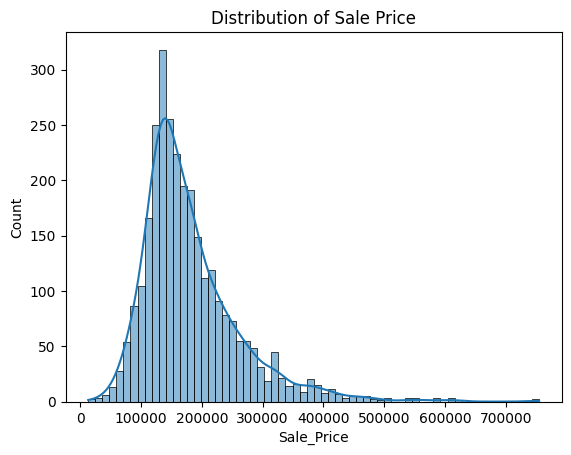

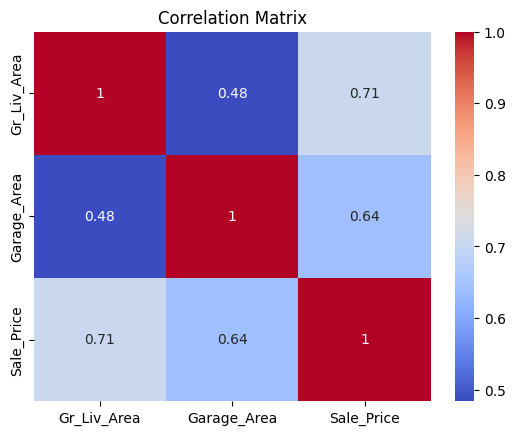

In [ ]:
# Explore the data with visualisations such as histograms and correlation matrices
sns.histplot(df['Sale_Price'], kde=True)
plt.title("Distribution of Sale Price")
plt.show()

# Make a heatmap of the correlation matrix
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [19]:
# Split the independent variables from the dependent variable

X = df[['Gr_Liv_Area', 'Garage_Area']]
y = df['Sale_Price']


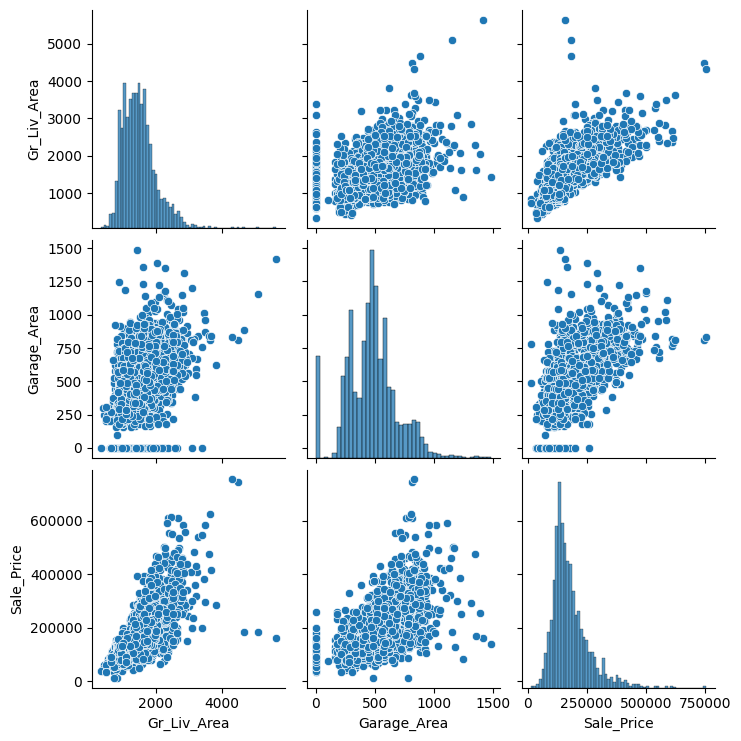

In [ ]:
# Explore relationships between the independent and dependent variables
# Plot the independent variables against the dependent variables
sns.pairplot(df)
plt.show()



In [ ]:
# Create a training and test set with a 75:25 split ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [22]:
# Build a multiple linear regression model using 'Gr_Liv_Area' and 'Garage_Area'
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [23]:
# Print the model intercept and coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: -5059.448195610428
Coefficients: [ 78.69286848 141.14571761]


In [24]:
# Generate predictions for the test set
y_pred = model.predict(X_test)

In [ ]:
# Evaluate the model
# Print the Squared Mean Error and Root Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)

Mean Squared Error: 2634371879.6902103
Root Mean Squared Error: 51326.13252223676


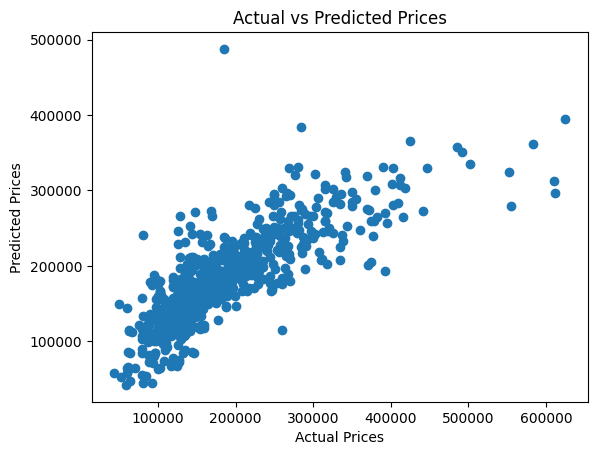

In [ ]:
# Generate a plot
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

In [27]:
# Print the coefficients
print("Model Coefficients:", model.coef_)

Model Coefficients: [ 78.69286848 141.14571761]


**Interpret coefficients in the context of the prediction:**

The coefficients imply that for every one square foot increase in the ground living area (Gr_Liv_Area), the sale price(Sale_Price) approximately increases by $78.69, if all other variables remain constant. 

The coefficients also imply that for every one square foot increase in the garage area(Garage_Area), the sale price approximately increases by $141.15, if all other variables remain constant.

The coefficient for the ground living area is smaller than that of the garage area, showing that garage area has a greater impact on the price than additional living areas

**Summarise findings**

When looking at the multiple linear regression model, it shows a strong relationship between the living area(Gr_Liv_area), garage area(Garage_Area), and sale price(Sale_Price). The coefficients, 78.69 (Living area and sale price) and 141.15(Garage area and sale price) indicates that both the living space and garage area contribute positively( Meaning price increases as the size of living area and garage increases). Garage area does have a higher impact on the sale price when compared to living area. The model above predicts sale prices well, as seen by tje error metrics and correlation plots. 

However, house prices seldomly only depend on the 2 variables mentioned above, situation, state, and more. If we incorporate more predictors the model's accuracy and predictive powers could be improved (Montgomery et al. 2021)

**References**

*De Cock, D. (2011). "Ames, Iowa: Alternative to the Boston Housing Data as an End of Semester
Regression Project," Journal of Statistics Education, Volume 19, Number 3.*
> The provided dataframe

Montgomery, D.C., Peck, E.A. and Vining, G.G., 2021. Introduction to linear regression analysis. John Wiley & Sons.
> More research had to be done to understand Linear Regression models. Using google scholar and searching 'Linear Regression' this source was found. And it states how more variables need to be considered for a more accurate representation